[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhimingkuang/Harvard-AM-115/blob/main/05_model_fitting/fit_yeast_ode.ipynb)

## Usain Bolt Assignment: Layla Dawit

## Task 1

As described in the assignment, we use the Hill-Keller model to model a sprint. This is the differential model showing how the rate of change of velocity relates to the maximum acceleration that the sprinter can produce, which comes from the upper limits of the individual's strength, as well as to the physical constraints of the body, as it is impossible for anyone's muscles to sustain accelerating forever. This leads us to the provided equation dv/dt = P_max - kv.

Note that this equation only takes into account the abilities and constraints of the body, not external factors. Also note that this equation assumes the runner is moving in one dimension, as in on a flat track, so no upwards and downwards hills, or any obstacles, are present. In other words, each step poses the same environmental challenge as all other steps. The only difference is the state of the runner's body at that point to determine how they will respond.

This model is thus useful in comparing runners as they would compete on a generic track (assuming they spend negligible time on curved parts). Note that we also consider t=0 to be when the runner starts running, to discard reaction time. This is useful in predicting the performance of runners over different distances, as we have a consistent type of motion, not two events (reaction then running).

## Task 2

## This code fits the yeast data to the logistic equation

It gives an example of how to read in the csv data and provides a template for the exercise of modeling running.

In [ ]:
# If running locally, you may need to install the following packages
# Uncomment any needed and run this block (change pip3 with conda if you use Anaconda)
# !pip3 install numpy
# !pip3 install pandas
# !pip3 install xlrd
# !pip3 install matplotlib
# !pip3 install scipy
# !pip3 install statsmodels

In [ ]:
# if you have already installed a previous version of xlrd, you may need to run this line.
# !pip install --upgrade --force-reinstall xlrd

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.interpolate import interp1d
from scipy.stats import chisquare

### Load data

>If working within Google Colab, run the following cell to clone the Github repo to access the data. If not can just skip to the next cell.

In [2]:
# If using Google Colab, run these lines to import data from github
!git clone https://github.com/zhimingkuang/Harvard-AM-115.git
%cd Harvard-AM-115/05_model_fitting

Cloning into 'Harvard-AM-115'...
remote: Enumerating objects: 484, done.
remote: Counting objects: 100% (158/158), done.
remote: Compressing objects: 100% (149/149), done.
remote: Total 484 (delta 82), reused 33 (delta 8), pack-reused 326 (from 1)
Receiving objects: 100% (484/484), 8.00 MiB | 27.50 MiB/s, done.
Resolving deltas: 100% (197/197), done.
/content/Harvard-AM-115/05_model_fitting


In [43]:
# Data import and setup
# Give the location of the file, replace with yours
loc = ('usain_bolt.csv')

# Read in the data from the Carlson 1913 paper
# Read in Excel, set up Series
running_data = pd.read_csv(loc)
#yeast_data = pd.read_excel(loc, index_col=None, header='infer')

# For simplicity, we shall assume the initial yeast amount is precisely
# known (it is hard-coded in ode45_logistic as the initial condition).
# Therefore, the actual data to be fitted are the second point and beyond.

# Separate time and amount into separate Series
# Make sure to start at hours = 1 for the data fitting
time = running_data.iloc[1:,1]
pos = running_data.iloc[1:,0]

time = time - 0.146 # Subtracting off reaction time from 2009 from csv file

# Initial guess of the parameters r and K
# We have normalized the parameters so they are of order 1
beta0 = [1,1]

In [4]:
# IGNORE THIS CELL -- left over from yeast sample code

# Define the ODE to be solved
def f(t, y, r, K):
    """Define the logistic differential equation

    Args:
        t (float): time
        y (numpy.ndarray): population
        r (numpy.float64): growth rate
        K (numpy.int64): carrying capacity

    Returns:
        numpy.ndarray: differential equation

    """

    ydot = r*y*(1-y/K)

    return ydot

In [5]:
# IGNORE THIS CELL -- left over from yeast sample code

# Define the curve to be fitted as a function of parameters and indepenent variable
# The following uses a numerical solution
def ode45_logistic(t, beta0, beta1):
    """Define the logistic differential equation

    Args:
        t (numpy.ndarray): time
        beta0 (numpy.int64): first unknown parameter, growth rate
        beta1 (numpy.int64): second unknown parameter, carrying capcity

    Returns:
        numpy.ndarray: y-values after data fitting

    """

    # Unpack parameters
    y0 = 9.6 # initial yeast population, assumed to be known to simplify the plots
    r = beta0*0.5 # growth rate, normalized so beta is of order 1
    K = beta1*600 # carrying capacity, normalized so beta is of order 1
    t0 = 0 # initial time

    # Solve the logistic ODE with RK45
    sol = solve_ivp(lambda t,y: f(t,y,r,K), [t0,max(t)], [y0], rtol=1e-10)
    # Unpack solution
    t, y = sol.t, sol.y

    # Do the interpolation, which creates a function yfit
    yfit = interp1d(t,y[0,:])
    y_new = yfit(time)

    return y_new

In [44]:
# Define the curve to be fitted as a function of parameters and indepenent variable
# The following uses the analytical solution
def analytical_logistic(t, beta0, beta1):
    """Define the logistic differential equation

    Args:
        t (numpy.ndarray): time
        beta0 (numpy.int64): first unknown parameter, growth rate
        beta1 (numpy.int64): second unknown parameter, carrying capcity

    Returns:
        numpy.ndarray: y-values after data fitting

    """

    # Unpack parameters
    #y0 = 9.6 # initial yeast population, assumed to be known to simplify the plots
    #r = beta0*0.5 # growth rate, normalized so beta is of order 1
    #K = beta1*600 # carrying capacity, normalized so beta is of order 1
    #t0 = 0 # initial time

    #yfit = K/(1+((K-y0)/y0)*np.exp(-r*t))

    Pmax = beta1
    k = beta0
    yfit = Pmax*(k*t + np.exp(-k*t) - 1)/k**2 # Equation 7 from Appendix 1

    return yfit

### Nonlinear curve fit

In [45]:
def loss_function(coeffs, y, t):
    """Define the residue to do least square fit

    Args:
        coeffs (numpy.ndarray): coefficients beta0 and beta1
        y (pandas.core.series.Series): yeast amount
        t (pandas.core.series.Series): time

    Returns:
        pandas.core.series.Series: residue

    """

    return y-analytical_logistic(t,coeffs[0],coeffs[1])
    #return y-ode45_logistic(t,coeffs[0],coeffs[1]) # example for using an ODE solver

In [46]:
nlinfit = least_squares(loss_function, beta0, args=(amount,time), method='lm')
beta = nlinfit.x # beta is the estimated optimal values for the parameters
J = nlinfit.jac # J is the Jacobian at the optimal point

# Find the predicted values given the best-fit beta parameters
yfit = analytical_logistic(time, beta[0], beta[1])
# yfit = ode45_logistic(time, beta[0], beta[1]) # example for using an ODE solver

In [52]:
print(f"Estimated beta parameters\n beta0: {beta[0]}\n beta1: {beta[1]}")

Estimated beta parameters
 beta0: 0.8057066822291437
 beta1: 9.848227997717519


In [53]:
# Compute the residue
residue = pos - analytical_logistic(time, *beta)
#residue = amount - ode45_logistic(time, *beta) # example for using an ODE solver
# Compute the mean squared error
MSE = residue.T@residue / (time.size-2)

# Compute the covariance matrix for the parameters
CovB = np.linalg.inv(J.T.dot(J)) * 0.01 # CovB is the covariance matrix for the parameters, multiply by 0.1^2 for position error

print('CovB=', CovB)

CovB= [[3.77692386e-05 3.67854064e-04]
 [3.67854064e-04 3.60791184e-03]]


>Note: Different from MATLAB `nlinfit`, we do not have residue and mse as returns; need to calculate it separately. Depending on which library functions we use, the return values can also vary, _e.g._ `scipy.optimize.curve_fit` would give a different `CovB` and does not return the Jacobian.

In [50]:
# Compare the covariance matrix with different library functions
from scipy.optimize import leastsq
from scipy.optimize import curve_fit

# Use leastsq
nlinfit_leastsq = leastsq(loss_function, beta0, args=(pos,time), full_output=True)
CovB_leastsq = nlinfit_leastsq[1]
# Use curve_fit
nlinfit_curve_fit = curve_fit(analytical_logistic, time, pos, p0=beta0, method='lm') # notice the func is different!
CovB_curve_fit = nlinfit_curve_fit[1]

print('leastsq CovB is\n',CovB_leastsq)
print('curve_fit CovB is\n',CovB_curve_fit)
print('least_squares CovB is\n',CovB)

leastsq CovB is
 [[0.00377692 0.0367854 ]
 [0.0367854  0.36079114]]
curve_fit CovB is
 [[7.70798304e-05 7.50720175e-04]
 [7.50720175e-04 7.36306197e-03]]
least_squares CovB is
 [[3.77692386e-05 3.67854064e-04]
 [3.67854064e-04 3.60791184e-03]]


In [37]:
# Customize for matplotlib
# If interested in the matplotlib object hierarchy, check: https://realpython.com/python-matplotlib-guide/
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['mathtext.default'] = 'regular'
# Change font size: http://www.futurile.net/2016/02/27/matplotlib-beautiful-plots-with-style/
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['figure.titlesize'] = 20

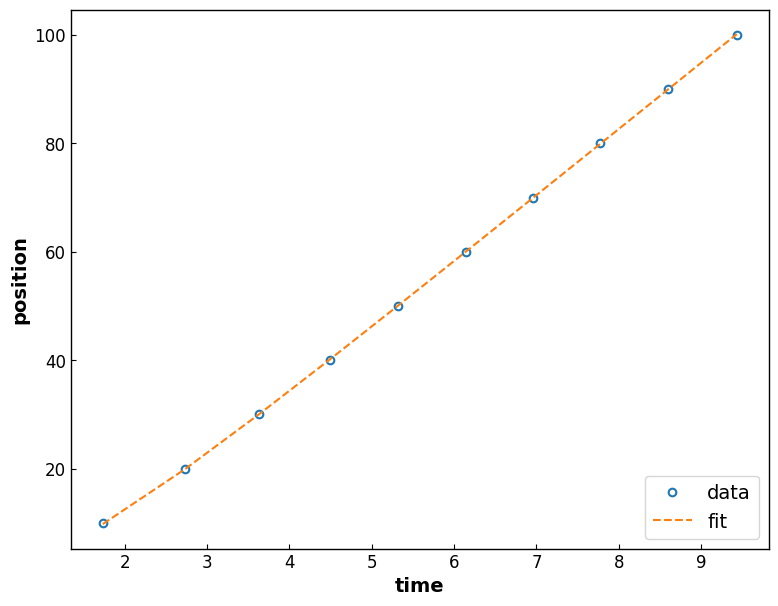

In [51]:
# Plot solution
fig, ax = plt.subplots(1,1,figsize=(9,7))

ax.plot(time, pos, 'o', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='data')
ax.plot(time, yfit, '--', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='fit')

# Set axes labels and legends
ax.set_xlabel('time')
ax.set_ylabel('position')
ax.legend(loc='lower right')

plt.show()

## Our work is not done!
Need to test whether the residual is consistent with our assumptions.

### Residue analysis

First, plot the residue

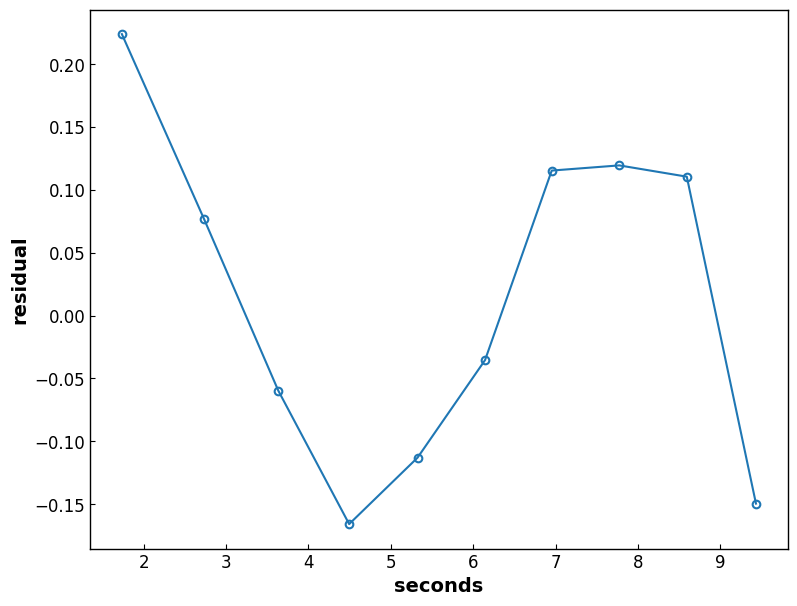

In [54]:
# Plot the residue
fig, ax = plt.subplots(1,1,figsize=(9,7))

ax.plot(time, residue, '-o', linewidth=1.5, mfc='none', ms=5.5, mew=1.5)

# Set axes labels and legends
ax.set_xlabel('seconds')
ax.set_ylabel('residual')

plt.show()

Next, check autocorrelation

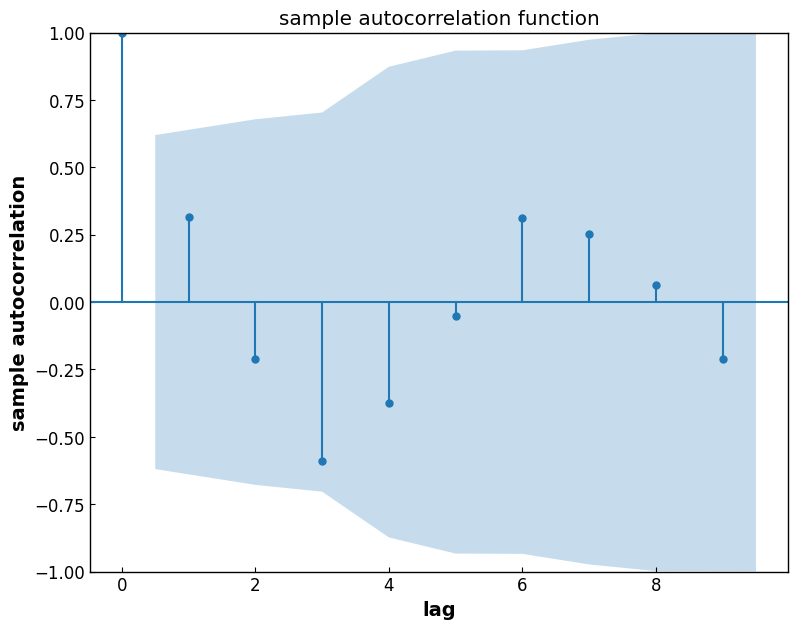

In [58]:
# https://www.statsmodels.org/dev/generated/statsmodels.graphics.tsaplots.plot_acf.html
from statsmodels.graphics.tsaplots import plot_acf

# Plot the autocorrelation
fig, ax = plt.subplots(1,1,figsize=(9,7))

fig = plot_acf(residue, lags=9, ax=ax)

# Set title, axes labels and legends
ax.set_title('sample autocorrelation function')
ax.set_xlabel('lag')
ax.set_ylabel('sample autocorrelation')

plt.show()

Now, test for heteroscedasticity

In [61]:
# Use the ARCH test by R. F. Engle, which assumes no autocorrelation
# https://www.statsmodels.org/dev/generated/statsmodels.stats.diagnostic.het_arch.html
from statsmodels.stats.diagnostic import het_arch

[fARCH,pARCH] = het_arch(residue)[-2:]

print("fARCH:",fARCH)
print("pARCH:",pARCH)

fARCH: 3.4306688851025062
pARCH: 0.11536945142547429


`fARCH` is the F-statistic for the F test. A small F-statistic means we cannot reject the null hypothesis that there is no heteroscedasticity. `pARCH` is the p-value. A smaller p-value indicates greater confidence in rejecting the null hypothesis.

>Note: We use `hARCH` in MATLAB, instead of F-statistic here.

### Extra note

If the residual has significant autocorrelation or heteroscedasticity, the parameter estimates are still unbiased but the uncertainty estimates are unreliable. In this case, try generalized least squares, which accounts for the noise (or innovation) covariance matrix, which is no longer just the identity matrix multiplied by a scalar. It is however not easy to get an accurate estimate of the noise covariance.

### Now, test the assumption of normal distribution

A visual way with quantile–quantile plot.

>Note: The reference line (red) is a bit different from MATLAB.

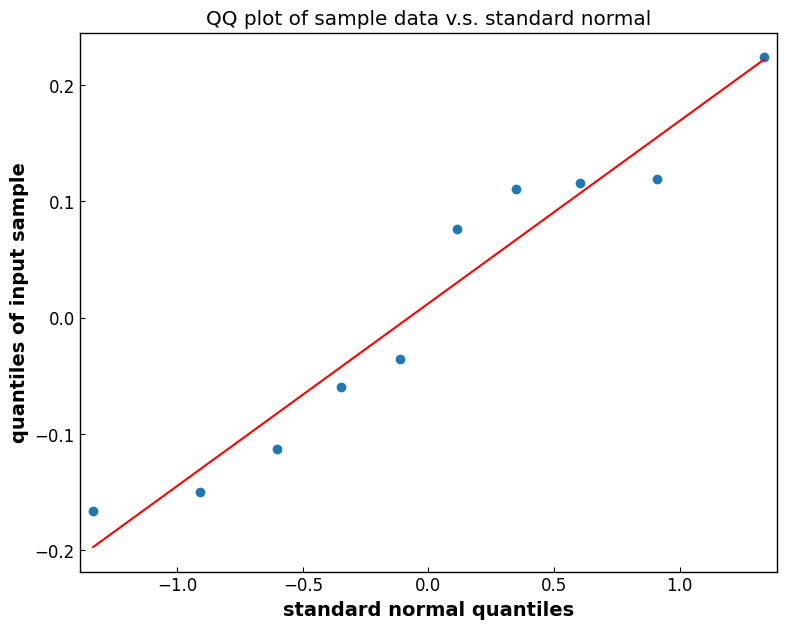

In [62]:
# https://www.statsmodels.org/dev/generated/statsmodels.graphics.gofplots.qqplot.html
from statsmodels.api import qqplot

# Plot the QQ plot
fig, ax = plt.subplots(1,1,figsize=(9,7))

fig = qqplot(residue, line='r', ax=ax)

# Set title, axes labels and legends
ax.set_title('QQ plot of sample data v.s. standard normal')
ax.set_xlabel('standard normal quantiles')
ax.set_ylabel('quantiles of input sample')

plt.show()

A more quantitative way with chi-square goodness of fit test.

If we know the measurement precision, we can compare MSE to the expected MSE to test the goodness of fit. While don't know the measurement precision here, we can still test if the residuals is consistent with a normal distribution with  the mean and standard deviation estimated from the residuals.

>Note: Chi-square test results are a bit different from MATLAB.

In [64]:
# Perform the chi-square goodness of fit test, using the predicted data and the actual data
# Need to normalize due to this change: https://github.com/scipy/scipy/issues/13362
import scipy.stats as stats

# Obtain the histogram (i.e. the observed frequency)
hist,bin_edge = np.histogram(residue,bins=5)
# Fit a normal distribution and compute the expected frequency for the bins
mu,std = stats.norm.fit(residue)
cdf = stats.norm.cdf(bin_edge, mu, std)
expected = len(residue) * np.diff(cdf) / (cdf[-1]-cdf[0])
# Perform chisquare test
h,p = chisquare(hist, expected)
print(f'Chi-square test statistics (h-value): {h}, p-value: {p}')

Chi-square test statistics (h-value): 5.896284168102094, p-value: 0.20702888088624616


>The null hypothesis: that the residuals are drawn from a normal distribution with the mean and standard deviation estimated from the residuals.
>
>The smaller the p-value: indicates greater confidence in rejecting the null hypothesis.

h is the chi-square statistic. A small h means we cannot reject the null hypothesis that residue is drawn from a normal distribution with the mean and standard deviation estimated from the residuals. p is the p-value. A smaller p-value indicates greater confidence in rejecting the null hypothesis.

### Extra note

Our dataset is quite small, and it is probably better to use the Lilliefors test, designed for small datasets ```[hNorm,pNorm] = lillietest(R)```

Lilliefors, H. W. _On the Kolmogorov-Smirnov test for normality with mean and variance unknown._ Journal of the American Statistical Association. Vol. 62, 1967, pp. 399–402.

### Now look at confidence intervals (95% confidence intervals)

Python implemenation of MATLAB `nlparci`.

In [65]:
# http://scipy.github.io/devdocs/reference/generated/scipy.stats.t.html
from scipy.stats.distributions import t

alpha = 0.05
dof = time.size-2 # statistical degree of freedom
tval = t.ppf(1.0-alpha/2., dof)

In [66]:
ci = np.zeros((2,2))
for i in range(2):
    ci[i,0] = beta[i] - CovB[i,i]**0.5*tval
    ci[i,1] = beta[i] + CovB[i,i]**0.5*tval

> `ci` and `beta` values are slightly different from the MATLAB results. The differences between software packages can factor in the difference in the nonlinear fit results.

In [67]:
ci

array([[0.79153475, 0.81987862],
       [9.70971579, 9.9867402 ]])

Optimal values:

In [68]:
beta

array([0.80570668, 9.848228  ])

### There is more to the parameter uncertainties

More information is contained in the eigenvalues and eigenvectors of the covariance matrix `CovB`.

>Note: The CovB is slightly different from the Matlab result so the eigenvalues are different. Eigenvectors may have different sign w.r.t. MATLAB results, which is linearly equivalent and is ok.

In [69]:
eigenvalues,eigenvectors = np.linalg.eig(CovB)
print("Eigenvalues:",eigenvalues)
print("Eigenvectors:",eigenvectors)

Eigenvalues: [2.61004472e-07 3.64542007e-03]
Eigenvectors: [[-0.99484176 -0.10143903]
 [ 0.10143903 -0.99484176]]


In [70]:
CovB

array([[3.77692386e-05, 3.67854064e-04],
       [3.67854064e-04, 3.60791184e-03]])

In [76]:
# Code to visualize the errors
b1 = np.arange(0.99, 1.01, 0.001)
b2 = np.arange(0.99, 1.01, 0.001)
B1,B2 = np.meshgrid(b1,b2)
rmse = np.zeros((len(b1),len(b2)))

for i in range(len(b1)):
    for j in range(len(b2)):
        rmse[i,j]=np.linalg.norm(pos-analytical_logistic(time,beta[0]*B1[i,j],beta[1]*B2[i,j]))

normalized_mse = np.power(rmse,2) / MSE / (time.size-2)
# time.size-2 is the number of data points minus the number of parameters

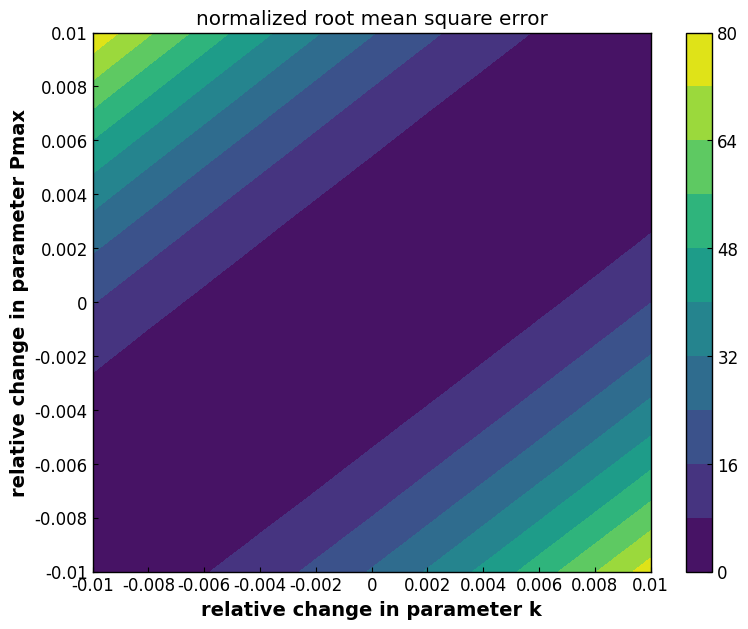

In [81]:
# Plot error
fig, ax = plt.subplots(1,1,figsize=(9,7))

img = ax.contourf(B1-1., B2-1., normalized_mse, 9)

# Set colorbar
cbar = fig.colorbar(img, ax=ax)

# Set xticks and yticks to match MATLAB results
ticks = [-0.01, -0.008, -0.006, -0.004, -0.002, 0, 0.002, 0.004, 0.006, 0.008, 0.01]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)
ax.set_yticks(ticks)
ax.set_yticklabels(ticks)

# Set title and axes labels
ax.set_title('normalized root mean square error')
ax.set_xlabel('relative change in parameter k')
ax.set_ylabel('relative change in parameter Pmax')

plt.show()

### The Jacobian describes how the parameters affect data

which linearized around the optimal values. In this case, we can reason a priori that noise shouldn't be corrected with the effect of r or K on the yeast population, but we can nontheless confirm that this is indeed the case.

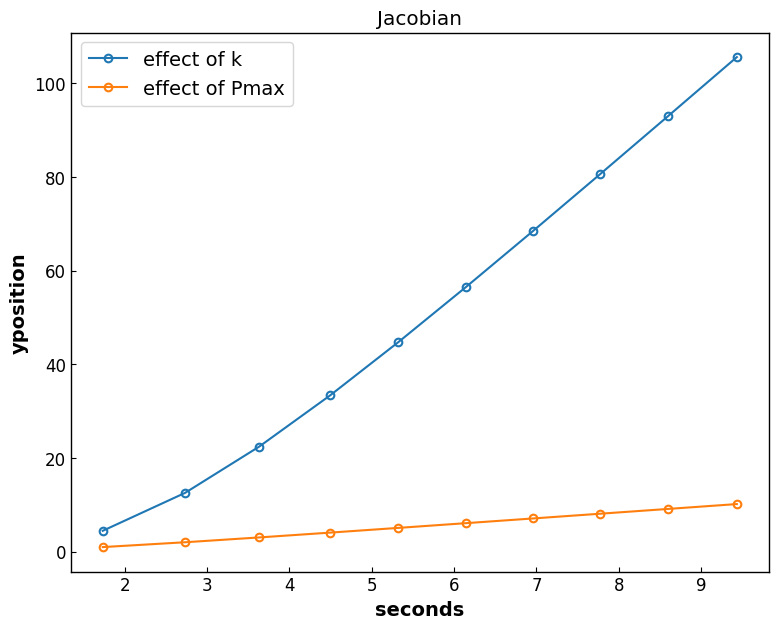

In [82]:
# Plot Jacobian
fig, ax = plt.subplots(1,1,figsize=(9,7))

ax.plot(time, np.abs(J[:,0]), '-o', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='effect of k')
ax.plot(time, np.abs(J[:,1]), '-o', linewidth=1.5, mfc='none', ms=5.5, mew=1.5, label='effect of Pmax')

# Set title, axes labels and legends
ax.set_title('Jacobian')
ax.set_xlabel('seconds')
ax.set_ylabel('yposition')
ax.legend(loc='upper left')

plt.show()

## Task 3

Method 1 (approximate):

From Task 2, we have estimated parameters beta0 (k): 0.8057066822291437 beta1 (Pmax): 9.848227997717519

For these races, the exponential term in our model will be very small, practically negligible

Then we say x(t) = 15.17(0.8057t+e^(−0.8057t)−1) = 15.17(0.8057t−1) = 12.22t - 15.17, where 15.17 = Pmax/k^2 for our estimated parameters.

Rearranging, we get t = (x(t) + 15.17)/12.22

In [96]:
dist = [200, 400, 1000, 1500, 2000, 3000];
t = []

for x in dist:
      tx = (x + 15.17)/12.22
      t.append(tx)

for d, t in zip(dist, t):
    print(f"{d} m : {t:.4f} seconds")

200 m : 17.6080 seconds
400 m : 33.9746 seconds
1000 m : 83.0745 seconds
1500 m : 123.9910 seconds
2000 m : 164.9075 seconds
3000 m : 246.7406 seconds


Method 2: Exact

In [98]:
from scipy.optimize import fsolve

beta0 = 0.8057066822291437
beta1 = 9.848227997717519

k = beta0
Pmax = beta1

def distance_model(t):
    return (Pmax / k**2) * (k*t + np.exp(-k*t) - 1)

# Function for fsolve to solve: distance_model(t) - d = 0
def getTime(d, initial_guess):
    func = lambda t: distance_model(t) - d
    t_solution = fsolve(func, initial_guess)
    return t_solution[0]

distances = [200, 400, 1000, 1500, 2000, 3000]

times = []

for d in distances:
    guess = (d + (Pmax/k**2)) / (Pmax/k) # guess linear approx
    t_exact = getTime(d, guess)
    times.append(t_exact)

for d, t in zip(distances, times):
    print(f"{d} m : {t:.4f} seconds")

200 m : 17.6036 seconds
400 m : 33.9661 seconds
1000 m : 83.0535 seconds
1500 m : 123.9597 seconds
2000 m : 164.8658 seconds
3000 m : 246.6782 seconds


The exact world records are:

200m: 19.19s

400m: 43.03s

1000m: 2:11.96 = 131.96s

1500m: 3:26.00 = 206.00s

2000m: 4:43.13 = 283.13s

3000m: 7:17.55 = 437.55s

These values are much higher than our expected values from our model. I think the issue is in the dataset we chose. Sprinting the 100m dash (as Usain Bolt did in our dataset) is very different than running long distances. Runners must pace themselves over long distances, not running to the full potential Pmax would suggest over the entire race. This difference becomes more pronounced over longer distances, as a runner's strategy for running the 200m dash could be roughly similar (a sprint) to running the 100m dash, but running the 3000m would have an entirely different strategy of pace and endurance. For larger distances the discrepancy we see is amplified, which makes sense under these different strategies.

## Task 4